# 2022-2025 July advection-ridge diagnostic: three-model comparison

This notebook computes empirical 2D cross-semivariogram ridge locations for July 2022-2025 and compares them with three fitted model estimate files:

1. `real_vecc_july_22_23_24_25_mm20.csv`
2. `real_dw_july_22_23_24_25.csv`
3. `real_july_corridor_width_4x4_lag643_all_fits.csv`

The empirical surface is

```text
gamma_hat(h, tau) = 0.5 * mean{ r(s,t) - r(s+h,t+tau) }^2
```

and the fitted advection prediction is

```text
h_model(tau) = v_hat * tau
```

because the model distance uses `h - v * tau`. The red X is the empirical ridge: the minimum of the pair-count-filtered, physically smoothed empirical surface. Ridge ambiguity diagnostics are saved so days with flat or multi-minimum surfaces can be flagged instead of over-interpreted.

All saved tables round numeric information to 4 decimals.


## Scope

The Vecchia and Debiased Whittle estimate files contain July days 1-28 for each year from 2022 through 2025. The corridor file contains additional July days, but the rigorous three-model intersection is:

```text
2022-07-01 through 2022-07-28
2023-07-01 through 2023-07-28
2024-07-01 through 2024-07-28
2025-07-01 through 2025-07-28
```

Outputs are separated into year-specific folders under the base output directory. The large-advection subset is defined model-independently as empirical ridge displacement from zero satisfying

```text
sqrt(ridge_lon_lag^2 + ridge_lat_lag^2) >= 1.0
```


In [1]:
import os
import sys
import json
import pickle
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple

PROJECT_ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
DATA_ROOT = Path('/Users/joonwonlee/Documents/GEMS_DATA')
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib_cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from scipy.ndimage import gaussian_filter
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

YEARS = [2022, 2023, 2024, 2025]
MONTH = 7
LAT_RANGE = [-3.0, 2.0]
LON_RANGE = [121.0, 131.0]
KEEP_ORI = False
CENTER_MODE = 'hourly_mean'
TAUS = [1, 2, 3]
MAX_LAT_OFFSET = 20
MAX_LON_OFFSET = 20
LAG_OFFSET_STRIDE = 1
SMOOTH_BANDWIDTH_DEG = 0.063
MIN_PAIR_COUNT = 1_000

# Ridge ambiguity is assessed after the same smoothing used for plotting.
RIDGE_NEAR_MIN_REL_TOL = 0.01
RIDGE_NEAR_MIN_ABS_TOL = 0.05
RIDGE_AMBIGUOUS_MIN_NEAR_CELLS = 5
LARGE_RIDGE_NORM_THRESHOLD = 1.0

ESTIMATE_FILES = {
    'Vecchia_mm20': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_vecc_july_22_23_24_25_mm20.csv',
    'Debiased_Whittle': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_dw_july_22_23_24_25.csv',
    'Corridor_4x4_lag643': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_july_corridor_width_4x4_lag643_all_fits.csv',
}

OUTPUT_DIR = PROJECT_ROOT / 'plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output directory: {OUTPUT_DIR}')


Output directory: /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526


In [2]:
def parse_day_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'day' in df.columns:
        parsed = df['day'].astype(str).str.extract(r'(?P<year>\d{4})-(?P<month>\d{1,2})-(?P<day_num>\d{1,2})')
        for col in ['year', 'month', 'day_num']:
            if col not in df.columns or df[col].isna().all():
                df[col] = pd.to_numeric(parsed[col], errors='coerce').astype('Int64')
    elif {'year', 'month', 'day_idx'}.issubset(df.columns):
        df['day_num'] = pd.to_numeric(df['day_idx'], errors='coerce').astype('Int64') + 1
    return df


def load_one_estimate_file(model_name: str, path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path)
    raw = parse_day_columns(raw)

    if 'status' in raw.columns:
        raw = raw.loc[raw['status'].astype(str).str.lower().eq('ok')].copy()

    # Carefully map all parameters to a common schema. For the corridor file,
    # sigma/ranges/advection/nugget are stored with est_* prefixes.
    if {'est_sigmasq', 'est_range_lat', 'est_range_lon', 'est_range_time', 'est_advec_lat', 'est_advec_lon', 'est_nugget'}.issubset(raw.columns):
        mapped = pd.DataFrame({
            'model': model_name,
            'source_file': str(path),
            'year': raw['year'],
            'month': raw['month'],
            'day_num': raw['day_num'],
            'day': raw['day'],
            'cov_name': raw.get('spec_name', model_name),
            'sigma': raw['est_sigmasq'],
            'range_lat': raw['est_range_lat'],
            'range_lon': raw['est_range_lon'],
            'range_time': raw['est_range_time'],
            'advec_lat': raw['est_advec_lat'],
            'advec_lon': raw['est_advec_lon'],
            'nugget': raw['est_nugget'],
            'loss': raw.get('loss', np.nan),
            'time': raw.get('total_s', raw.get('time', np.nan)),
            'valid_rate': raw.get('valid_rate', np.nan),
            'n_valid_o3': raw.get('n_valid_o3', np.nan),
        })
    else:
        mapped = pd.DataFrame({
            'model': model_name,
            'source_file': str(path),
            'year': raw['year'],
            'month': raw['month'],
            'day_num': raw['day_num'],
            'day': raw['day'],
            'cov_name': raw.get('cov_name', model_name),
            'sigma': raw['sigma'],
            'range_lat': raw['range_lat'],
            'range_lon': raw['range_lon'],
            'range_time': raw['range_time'],
            'advec_lat': raw['advec_lat'],
            'advec_lon': raw['advec_lon'],
            'nugget': raw['nugget'],
            'loss': raw.get('loss', np.nan),
            'time': raw.get('time', np.nan),
            'valid_rate': raw.get('valid_rate', np.nan),
            'n_valid_o3': raw.get('n_valid_o3', np.nan),
        })

    numeric_cols = ['year', 'month', 'day_num', 'sigma', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget', 'loss', 'time', 'valid_rate', 'n_valid_o3']
    for col in numeric_cols:
        mapped[col] = pd.to_numeric(mapped[col], errors='coerce')
    return mapped


def load_all_estimates(files: Dict[str, Path]) -> pd.DataFrame:
    frames = [load_one_estimate_file(name, path) for name, path in files.items()]
    out = pd.concat(frames, ignore_index=True)
    out = out.loc[out['year'].isin(YEARS) & out['month'].eq(MONTH)].copy()
    out = out.sort_values(['year', 'day_num', 'model']).reset_index(drop=True)
    return out


estimates = load_all_estimates(ESTIMATE_FILES)
param_cols = ['year', 'model', 'day', 'sigma', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget', 'loss', 'time', 'valid_rate', 'n_valid_o3']
param_table = estimates[param_cols].round(4)
param_csv = OUTPUT_DIR / 'three_model_parameter_estimates_2022_2025_07.csv'
param_table.to_csv(param_csv, index=False, float_format='%.4f')
print(f'Saved {param_csv}')
display(param_table.head(12))


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/three_model_parameter_estimates_2022_2025_07.csv


,year,model,day,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget,loss,time,valid_rate,n_valid_o3
0,2022,Corridor_4x4_lag643,2022-07-01,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072,1.2093,35.4315,0.9920,143853.0
1,2022,Debiased_Whittle,2022-07-1,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864,115551.0880,111.7636,NaN,NaN
2,2022,Vecchia_mm20,2022-07-1,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723,1.2591,54.4569,NaN,NaN
3,2022,Corridor_4x4_lag643,2022-07-02,7.0359,0.1715,0.1787,1.0242,0.0075,-0.2795,1.8939,1.2553,24.8630,0.9748,141347.0
4,2022,Debiased_Whittle,2022-07-2,6.4137,0.1200,0.1311,0.8784,0.0299,-0.2897,1.4776,246956.5280,94.1755,NaN,NaN
5,2022,Vecchia_mm20,2022-07-2,7.8296,0.3299,0.3572,1.6104,0.0263,-0.1932,2.6110,1.3469,39.9762,NaN,NaN
6,2022,Corridor_4x4_lag643,2022-07-03,8.8221,0.1898,0.2358,1.0405,0.0182,-0.1128,1.5376,1.2257,21.7607,0.8845,128254.0
7,2022,Debiased_Whittle,2022-07-3,5.9562,0.1507,0.1610,0.8402,0.0092,-0.0588,1.0284,-79128.9280,75.2054,NaN,NaN
8,2022,Vecchia_mm20,2022-07-3,10.2319,0.3491,0.5161,1.8609,0.0359,-0.1294,2.2946,1.3337,33.3842,NaN,NaN
9,2022,Corridor_4x4_lag643,2022-07-04,7.6722,0.1842,0.1821,1.2079,0.0455,-0.1758,2.1201,1.2960,27.8050,0.9776,141753.0


In [3]:
# Determine common days across all three estimate sources, year by year.
COMMON_DAYS_BY_YEAR = {}
for year in YEARS:
    year_est = estimates.loc[estimates['year'].eq(year)]
    model_days = {
        model: set(year_est.loc[year_est['model'].eq(model), 'day_num'].dropna().astype(int))
        for model in year_est['model'].unique()
    }
    COMMON_DAYS_BY_YEAR[year] = sorted(set.intersection(*model_days.values())) if model_days else []
    print(year, COMMON_DAYS_BY_YEAR[year], 'n=', len(COMMON_DAYS_BY_YEAR[year]))


2022 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28] n= 28
2023 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28] n= 28
2024 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28] n= 28
2025 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28] n= 28


In [4]:
DATA_CACHE = {}


def load_tco_grid_dicts(data_root: Path, year: int, month: int) -> Dict[str, pd.DataFrame]:
    path = data_root / f'pickle_{year}' / f'tco_grid_{str(year)[2:]}_{month:02d}.pkl'
    with open(path, 'rb') as f:
        raw = pickle.load(f)
    out = {}
    for key, df in raw.items():
        tmp = df.copy()
        mask = (
            tmp['Latitude'].between(LAT_RANGE[0], LAT_RANGE[1])
            & tmp['Longitude'].between(LON_RANGE[0], LON_RANGE[1])
        )
        out[key] = tmp.loc[mask].reset_index(drop=True)
    return out


def load_year_data(year: int):
    if year not in DATA_CACHE:
        df_map = load_tco_grid_dicts(DATA_ROOT, year, MONTH)
        ozone_vals = [pd.to_numeric(df['ColumnAmountO3'], errors='coerce').to_numpy() for df in df_map.values()]
        monthly_mean = float(np.nanmean(np.concatenate(ozone_vals)))
        DATA_CACHE[year] = {'df_map': df_map, 'monthly_mean': monthly_mean}
        print(f'Loaded {len(df_map)} hourly maps for {year}-{MONTH:02d}; monthly mean={monthly_mean:.4f}')
    return DATA_CACHE[year]['df_map'], DATA_CACHE[year]['monthly_mean']


for year in YEARS:
    load_year_data(year)


Loaded 240 hourly maps for 2022-07; monthly mean=250.6500


Loaded 248 hourly maps for 2023-07; monthly mean=249.7131
Loaded 248 hourly maps for 2024-07; monthly mean=257.9726


Loaded 247 hourly maps for 2025-07; monthly mean=241.4412


In [5]:
def load_day_map(year: int, day: int, keep_ori: bool = KEEP_ORI) -> Dict[str, np.ndarray]:
    df_map, monthly_mean = load_year_data(year)
    day_token = f'day{int(day):02d}'
    day_keys = [k for k in sorted(df_map) if day_token in k]
    if not day_keys:
        raise ValueError(f'No keys found for {year}-{MONTH:02d}-{day:02d}')
    out = {}
    coord_cols = ['Source_Latitude', 'Source_Longitude'] if keep_ori else ['Latitude', 'Longitude']
    for key in day_keys:
        tmp = df_map[key].copy()
        ozone = pd.to_numeric(tmp['ColumnAmountO3'], errors='coerce').to_numpy(dtype=float) - monthly_mean
        hours = pd.to_numeric(tmp['Hours_elapsed'], errors='coerce')
        if hours.notna().any():
            hours = hours.fillna(hours.dropna().median())
        arr = np.column_stack([
            pd.to_numeric(tmp[coord_cols[0]], errors='coerce').to_numpy(dtype=float),
            pd.to_numeric(tmp[coord_cols[1]], errors='coerce').to_numpy(dtype=float),
            ozone,
            hours.to_numpy(dtype=float),
        ])
        out[key] = arr
    return out


def as_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def infer_grid_from_tensor(tensor, digits: int = 6):
    arr = as_numpy(tensor)
    lats = np.sort(np.unique(np.round(arr[:, 0], digits)))
    lons = np.sort(np.unique(np.round(arr[:, 1], digits)))
    return lats, lons


def tensor_to_grid(tensor, lats, lons, value_col: int = 2, digits: int = 6):
    arr = as_numpy(tensor)
    lat_to_i = {float(v): i for i, v in enumerate(lats)}
    lon_to_j = {float(v): j for j, v in enumerate(lons)}
    grid = np.full((len(lats), len(lons)), np.nan, dtype=float)
    for lat, lon, val in zip(np.round(arr[:, 0], digits), np.round(arr[:, 1], digits), arr[:, value_col].astype(float)):
        i = lat_to_i.get(float(lat))
        j = lon_to_j.get(float(lon))
        if i is not None and j is not None:
            grid[i, j] = val
    return grid


In [6]:
def build_hourly_grids(day_map, center_mode: str = CENTER_MODE):
    keys = sorted(day_map)
    lats, lons = infer_grid_from_tensor(day_map[keys[0]])
    grids = []
    for key in keys:
        grid = tensor_to_grid(day_map[key], lats, lons)
        if center_mode == 'hourly_mean':
            grid = grid - np.nanmean(grid)
        elif center_mode == 'none':
            pass
        else:
            raise ValueError(f'Unknown center_mode: {center_mode}')
        grids.append(grid)
    lat_step = float(np.nanmedian(np.diff(lats)))
    lon_step = float(np.nanmedian(np.diff(lons)))
    return keys, grids, lats, lons, lat_step, lon_step


def make_lag_offsets():
    lat_offsets = np.arange(-MAX_LAT_OFFSET, MAX_LAT_OFFSET + 1, LAG_OFFSET_STRIDE, dtype=int)
    lon_offsets = np.arange(-MAX_LON_OFFSET, MAX_LON_OFFSET + 1, LAG_OFFSET_STRIDE, dtype=int)
    if 0 not in lat_offsets:
        lat_offsets = np.sort(np.append(lat_offsets, 0))
    if 0 not in lon_offsets:
        lon_offsets = np.sort(np.append(lon_offsets, 0))
    return lat_offsets, lon_offsets


def shifted_sum_half_sq(cur, nxt, di: int, dj: int):
    nlat, nlon = cur.shape
    if abs(di) >= nlat or abs(dj) >= nlon:
        return 0.0, 0
    if di >= 0:
        cur_i = slice(0, nlat - di); nxt_i = slice(di, nlat)
    else:
        cur_i = slice(-di, nlat); nxt_i = slice(0, nlat + di)
    if dj >= 0:
        cur_j = slice(0, nlon - dj); nxt_j = slice(dj, nlon)
    else:
        cur_j = slice(-dj, nlon); nxt_j = slice(0, nlon + dj)
    c = cur[cur_i, cur_j]
    n = nxt[nxt_i, nxt_j]
    mask = np.isfinite(c) & np.isfinite(n)
    n_valid = int(mask.sum())
    if n_valid == 0:
        return 0.0, 0
    diff = c[mask] - n[mask]
    return float(0.5 * np.sum(diff * diff)), n_valid


def compute_surfaces(day_map, taus=TAUS, lat_offsets=None, lon_offsets=None):
    if lat_offsets is None or lon_offsets is None:
        lat_offsets, lon_offsets = make_lag_offsets()
    keys, grids, lats, lons, lat_step, lon_step = build_hourly_grids(day_map)
    surfaces = {}
    for tau in taus:
        starts = [h for h in range(len(grids)) if h + tau < len(grids)]
        sum_half_sq = np.zeros((len(lat_offsets), len(lon_offsets)), dtype=float)
        counts = np.zeros_like(sum_half_sq, dtype=int)
        for h in starts:
            cur = grids[h]
            nxt = grids[h + tau]
            for ii, di in enumerate(lat_offsets):
                for jj, dj in enumerate(lon_offsets):
                    ss, n = shifted_sum_half_sq(cur, nxt, int(di), int(dj))
                    if n > 0:
                        sum_half_sq[ii, jj] += ss
                        counts[ii, jj] += n
        gamma = np.full_like(sum_half_sq, np.nan, dtype=float)
        valid = counts > 0
        gamma[valid] = sum_half_sq[valid] / counts[valid]
        surfaces[tau] = {
            'gamma': gamma,
            'counts': counts,
            'lat_offsets': lat_offsets,
            'lon_offsets': lon_offsets,
            'lat_lags': lat_offsets * lat_step,
            'lon_lags': lon_offsets * lon_step,
            'lat_step': lat_step,
            'lon_step': lon_step,
            'keys': keys,
            'hour_starts': starts,
        }
    return surfaces


In [7]:
def lag_edges_from_centers(centers):
    centers = np.asarray(centers, dtype=float)
    mids = 0.5 * (centers[:-1] + centers[1:])
    first = centers[0] - (mids[0] - centers[0])
    last = centers[-1] + (centers[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])


def smoothing_sigma(surface):
    if SMOOTH_BANDWIDTH_DEG is None or SMOOTH_BANDWIDTH_DEG <= 0:
        return (0.0, 0.0)
    return (SMOOTH_BANDWIDTH_DEG / abs(surface['lat_step']), SMOOTH_BANDWIDTH_DEG / abs(surface['lon_step']))


def nan_gaussian_filter(arr, sigma):
    if sigma[0] <= 0 and sigma[1] <= 0:
        return arr.copy()
    mask = np.isfinite(arr)
    vals = gaussian_filter(np.where(mask, arr, 0.0), sigma=sigma, mode='nearest')
    weights = gaussian_filter(mask.astype(float), sigma=sigma, mode='nearest')
    out = vals / np.maximum(weights, 1e-12)
    out[weights <= 1e-12] = np.nan
    return out


def smooth_surface_for_ridge(surface):
    gamma = np.where(surface['counts'] >= MIN_PAIR_COUNT, surface['gamma'], np.nan)
    return nan_gaussian_filter(gamma, smoothing_sigma(surface))


def near_min_mask(smoothed, gamma_min):
    tol = max(RIDGE_NEAR_MIN_ABS_TOL, RIDGE_NEAR_MIN_REL_TOL * abs(float(gamma_min)))
    return np.isfinite(smoothed) & (smoothed <= float(gamma_min) + tol), tol


def extract_ridge(surface):
    smoothed = smooth_surface_for_ridge(surface)
    finite = np.isfinite(smoothed)
    if not finite.any():
        return {
            'lat_lag': np.nan, 'lon_lag': np.nan, 'ridge_norm': np.nan,
            'gamma_min': np.nan, 'gamma_second_min': np.nan, 'gamma_gap': np.nan, 'gamma_rel_gap': np.nan,
            'near_min_count': 0, 'near_min_tol': np.nan, 'is_ambiguous': True,
            'n_pairs': 0, 'row': -1, 'col': -1,
        }
    flat_idx = int(np.nanargmin(smoothed))
    row, col = np.unravel_index(flat_idx, smoothed.shape)
    finite_vals = np.sort(smoothed[finite].ravel())
    gamma_min = float(smoothed[row, col])
    gamma_second = float(finite_vals[1]) if finite_vals.size > 1 else np.nan
    gamma_gap = gamma_second - gamma_min if np.isfinite(gamma_second) else np.nan
    gamma_rel_gap = gamma_gap / max(abs(gamma_min), 1e-12) if np.isfinite(gamma_gap) else np.nan
    nm, tol = near_min_mask(smoothed, gamma_min)
    near_count = int(nm.sum())
    lat_lag = float(surface['lat_lags'][row])
    lon_lag = float(surface['lon_lags'][col])
    return {
        'lat_lag': lat_lag,
        'lon_lag': lon_lag,
        'ridge_norm': float(np.sqrt(lat_lag ** 2 + lon_lag ** 2)),
        'gamma_min': gamma_min,
        'gamma_second_min': gamma_second,
        'gamma_gap': gamma_gap,
        'gamma_rel_gap': gamma_rel_gap,
        'near_min_count': near_count,
        'near_min_tol': float(tol),
        'is_ambiguous': bool(near_count >= RIDGE_AMBIGUOUS_MIN_NEAR_CELLS),
        'n_pairs': int(surface['counts'][row, col]),
        'row': int(row),
        'col': int(col),
    }


def get_estimate_rows(year: int, day: int):
    return estimates.loc[estimates['year'].eq(year) & estimates['day_num'].eq(day)].copy()


def compare_day_ridges(year: int, day: int, ridge_rows):
    rows = []
    est_day = get_estimate_rows(year, day)
    for ridge in ridge_rows:
        tau = int(ridge['tau'])
        for _, est in est_day.iterrows():
            model_lat = float(est['advec_lat']) * tau
            model_lon = float(est['advec_lon']) * tau
            err_lat = float(ridge['lat_lag']) - model_lat
            err_lon = float(ridge['lon_lag']) - model_lon
            model_norm = float(np.sqrt(model_lat ** 2 + model_lon ** 2))
            rows.append({
                'year': year,
                'month': MONTH,
                'day_num': day,
                'tau': tau,
                'model': est['model'],
                'ridge_lat_lag': ridge['lat_lag'],
                'ridge_lon_lag': ridge['lon_lag'],
                'ridge_norm': ridge['ridge_norm'],
                'large_empirical_ridge': bool(ridge['ridge_norm'] >= LARGE_RIDGE_NORM_THRESHOLD),
                'model_lat_lag': model_lat,
                'model_lon_lag': model_lon,
                'model_norm': model_norm,
                'model_norm_ge_1': bool(model_norm >= LARGE_RIDGE_NORM_THRESHOLD),
                'norm_bias': model_norm - float(ridge['ridge_norm']),
                'abs_norm_bias': abs(model_norm - float(ridge['ridge_norm'])),
                'overestimated_norm': bool(model_norm > float(ridge['ridge_norm'])),
                'err_lat': err_lat,
                'err_lon': err_lon,
                'err_euclid': float(np.sqrt(err_lat ** 2 + err_lon ** 2)),
                'ridge_gamma_min': ridge['gamma_min'],
                'ridge_gamma_gap': ridge['gamma_gap'],
                'ridge_gamma_rel_gap': ridge['gamma_rel_gap'],
                'ridge_near_min_count': ridge['near_min_count'],
                'ridge_is_ambiguous': ridge['is_ambiguous'],
                'ridge_n_pairs': ridge['n_pairs'],
                'sigma': est['sigma'],
                'range_lat': est['range_lat'],
                'range_lon': est['range_lon'],
                'range_time': est['range_time'],
                'advec_lat': est['advec_lat'],
                'advec_lon': est['advec_lon'],
                'nugget': est['nugget'],
            })
    return rows


In [8]:
MODEL_STYLE = {
    'Vecchia_mm20': dict(marker='*', facecolor='white', edgecolor='black', s=250, linewidth=1.4, label='Vecchia mm20'),
    'Debiased_Whittle': dict(marker='o', facecolor='#ffb000', edgecolor='black', s=125, linewidth=1.2, label='Debiased Whittle'),
    'Corridor_4x4_lag643': dict(marker='^', facecolor='#3b82f6', edgecolor='black', s=145, linewidth=1.2, label='Corridor 4x4'),
}


def plot_day_surfaces(year: int, day: int, surfaces, ridge_rows, daily_dir: Path, save=True):
    taus = list(surfaces.keys())
    fig, axes = plt.subplots(1, len(taus), figsize=(6.6 * len(taus), 5.35), constrained_layout=True)
    axes = np.atleast_1d(axes)
    vals = []
    for surface in surfaces.values():
        g = surface['gamma'][(surface['counts'] >= MIN_PAIR_COUNT) & np.isfinite(surface['gamma'])]
        if g.size:
            vals.append(g)
    vals = np.concatenate(vals) if vals else np.array([0, 1])
    vmin, vmax = np.nanpercentile(vals, [2, 98])
    est_day = get_estimate_rows(year, day)
    last_im = None
    for ax, tau in zip(axes, taus):
        surface = surfaces[tau]
        smoothed = smooth_surface_for_ridge(surface)
        last_im = ax.pcolormesh(
            lag_edges_from_centers(surface['lon_lags']),
            lag_edges_from_centers(surface['lat_lags']),
            smoothed,
            shading='auto', cmap='viridis', vmin=vmin, vmax=vmax,
        )
        ridge = next(r for r in ridge_rows if r['tau'] == tau)
        if ridge['is_ambiguous']:
            nm, _ = near_min_mask(smoothed, ridge['gamma_min'])
            rr, cc = np.where(nm)
            if len(rr) <= 160:
                ax.scatter(surface['lon_lags'][cc], surface['lat_lags'][rr], s=13, color='crimson', alpha=0.28, label='near-min cells', zorder=5)
        ax.scatter(
            ridge['lon_lag'], ridge['lat_lag'],
            marker='x', s=125, lw=3.0, color='crimson',
            label='empirical ridge', zorder=8,
        )
        for _, est in est_day.iterrows():
            style = MODEL_STYLE.get(
                est['model'],
                dict(marker='s', facecolor='white', edgecolor='black', s=120, linewidth=1.2, label=est['model']),
            )
            mlon = float(est['advec_lon']) * tau
            mlat = float(est['advec_lat']) * tau
            ax.scatter(
                mlon, mlat,
                marker=style['marker'], s=style['s'],
                facecolors=style['facecolor'], edgecolors=style['edgecolor'],
                linewidths=style['linewidth'], label=style['label'], zorder=7,
            )
            ax.plot([0, mlon], [0, mlat], color=style['edgecolor'], alpha=0.45, lw=1.0, zorder=6)
        ax.axhline(0, color='white', lw=0.85, alpha=0.7)
        ax.axvline(0, color='white', lw=0.85, alpha=0.7)
        ax.set_aspect('equal', adjustable='box')
        amb = ', ambiguous' if ridge['is_ambiguous'] else ''
        ax.set_title(f'{year}-07-{day:02d}, tau={tau}\nridge=({ridge["lon_lag"]:.4f}, {ridge["lat_lag"]:.4f}), near={ridge["near_min_count"]}{amb}')
        ax.set_xlabel('longitude lag')
        ax.set_ylabel('latitude lag')
        ax.legend(fontsize=7.2, loc='upper right', frameon=True, framealpha=0.88)
    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.85, label=f'empirical semivariance, smoothed bw={SMOOTH_BANDWIDTH_DEG} deg')
    if save:
        path = daily_dir / f'advection_ridge_three_models_{year}_07_day{day:02d}.png'
        fig.savefig(path, bbox_inches='tight')
    return fig


In [9]:
RUN_ALL_DAYS = True
SHOW_EACH_DAY = False

lat_offsets, lon_offsets = make_lag_offsets()
print(f'lag bins: lat={len(lat_offsets)}, lon={len(lon_offsets)}')

all_ridge_rows = []
all_comparison_rows = []

if RUN_ALL_DAYS:
    for year in YEARS:
        year_dir = OUTPUT_DIR / f'year_{year}'
        daily_dir = year_dir / 'daily_surfaces'
        year_dir.mkdir(parents=True, exist_ok=True)
        daily_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = year_dir / f'advection_ridge_three_models_{year}_07_days01_28.pdf'
        print(f'\n=== Processing {year}-07; output={year_dir} ===')
        with PdfPages(pdf_path) as pdf:
            for day in COMMON_DAYS_BY_YEAR[year]:
                print(f'Processing {year}-07-{day:02d}...')
                day_map = load_day_map(year, day)
                surfaces = compute_surfaces(day_map, taus=TAUS, lat_offsets=lat_offsets, lon_offsets=lon_offsets)
                ridge_rows = []
                for tau, surface in surfaces.items():
                    ridge = extract_ridge(surface)
                    ridge['year'] = year
                    ridge['month'] = MONTH
                    ridge['day_num'] = day
                    ridge['tau'] = tau
                    ridge['lat_step'] = surface['lat_step']
                    ridge['lon_step'] = surface['lon_step']
                    ridge_rows.append(ridge)
                    all_ridge_rows.append(ridge.copy())
                all_comparison_rows.extend(compare_day_ridges(year, day, ridge_rows))
                fig = plot_day_surfaces(year, day, surfaces, ridge_rows, daily_dir=daily_dir, save=True)
                pdf.savefig(fig, bbox_inches='tight')
                if SHOW_EACH_DAY:
                    plt.show()
                else:
                    plt.close(fig)
        print(f'Saved {pdf_path}')

ridge_summary = pd.DataFrame(all_ridge_rows).round(4)
comparison_summary = pd.DataFrame(all_comparison_rows).round(4)

ridge_csv = OUTPUT_DIR / 'empirical_ridge_summary_2022_2025_07_days01_28.csv'
comparison_csv = OUTPUT_DIR / 'ridge_vs_three_models_2022_2025_07_days01_28.csv'
ridge_summary.to_csv(ridge_csv, index=False, float_format='%.4f')
comparison_summary.to_csv(comparison_csv, index=False, float_format='%.4f')
print(f'Saved {ridge_csv}')
print(f'Saved {comparison_csv}')

for year in YEARS:
    year_dir = OUTPUT_DIR / f'year_{year}'
    ridge_summary.loc[ridge_summary['year'].eq(year)].to_csv(year_dir / f'empirical_ridge_summary_{year}_07_days01_28.csv', index=False, float_format='%.4f')
    comparison_summary.loc[comparison_summary['year'].eq(year)].to_csv(year_dir / f'ridge_vs_three_models_{year}_07_days01_28.csv', index=False, float_format='%.4f')

display(ridge_summary.head())
display(comparison_summary.head(9))


lag bins: lat=41, lon=41

=== Processing 2022-07; output=/Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/year_2022 ===
Processing 2022-07-01...


Processing 2022-07-02...


Processing 2022-07-03...


Processing 2022-07-04...


Processing 2022-07-05...


...

Processing 2025-07-27...


Processing 2025-07-28...


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/year_2025/advection_ridge_three_models_2025_07_days01_28.pdf
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/empirical_ridge_summary_2022_2025_07_days01_28.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/ridge_vs_three_models_2022_2025_07_days01_28.csv


,lat_lag,lon_lag,ridge_norm,gamma_min,gamma_second_min,gamma_gap,gamma_rel_gap,near_min_count,near_min_tol,is_ambiguous,n_pairs,row,col,year,month,day_num,tau,lat_step,lon_step
0,0.000,-0.063,0.0630,5.0179,5.0307,0.0128,0.0026,8,0.0502,True,124498,20,19,2022,7,1,1,0.044,0.063
1,-0.044,-0.567,0.5687,5.7362,5.7394,0.0032,0.0006,29,0.0574,True,100337,19,11,2022,7,1,2,0.044,0.063
2,-0.044,-0.945,0.9460,6.0579,6.0595,0.0016,0.0003,50,0.0606,True,80152,19,5,2022,7,1,3,0.044,0.063
3,0.000,-0.315,0.3150,6.3471,6.3781,0.0311,0.0049,6,0.0635,True,118210,20,15,2022,7,2,1,0.044,0.063
4,0.000,-0.630,0.6300,7.4302,7.4305,0.0003,0.0000,15,0.0743,True,97756,20,10,2022,7,2,2,0.044,0.063


,year,month,day_num,tau,model,ridge_lat_lag,ridge_lon_lag,ridge_norm,large_empirical_ridge,model_lat_lag,...,ridge_near_min_count,ridge_is_ambiguous,ridge_n_pairs,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget
0,2022,7,1,1,Corridor_4x4_lag643,0.000,-0.063,0.0630,False,0.0038,...,8,True,124498,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072
1,2022,7,1,1,Debiased_Whittle,0.000,-0.063,0.0630,False,-0.0156,...,8,True,124498,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864
2,2022,7,1,1,Vecchia_mm20,0.000,-0.063,0.0630,False,-0.0009,...,8,True,124498,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723
3,2022,7,1,2,Corridor_4x4_lag643,-0.044,-0.567,0.5687,False,0.0077,...,29,True,100337,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072
4,2022,7,1,2,Debiased_Whittle,-0.044,-0.567,0.5687,False,-0.0312,...,29,True,100337,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864
5,2022,7,1,2,Vecchia_mm20,-0.044,-0.567,0.5687,False,-0.0018,...,29,True,100337,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723
6,2022,7,1,3,Corridor_4x4_lag643,-0.044,-0.945,0.9460,False,0.0115,...,50,True,80152,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072
7,2022,7,1,3,Debiased_Whittle,-0.044,-0.945,0.9460,False,-0.0468,...,50,True,80152,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864
8,2022,7,1,3,Vecchia_mm20,-0.044,-0.945,0.9460,False,-0.0027,...,50,True,80152,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/summary_lon_ridge_vs_models_by_year_tau.png


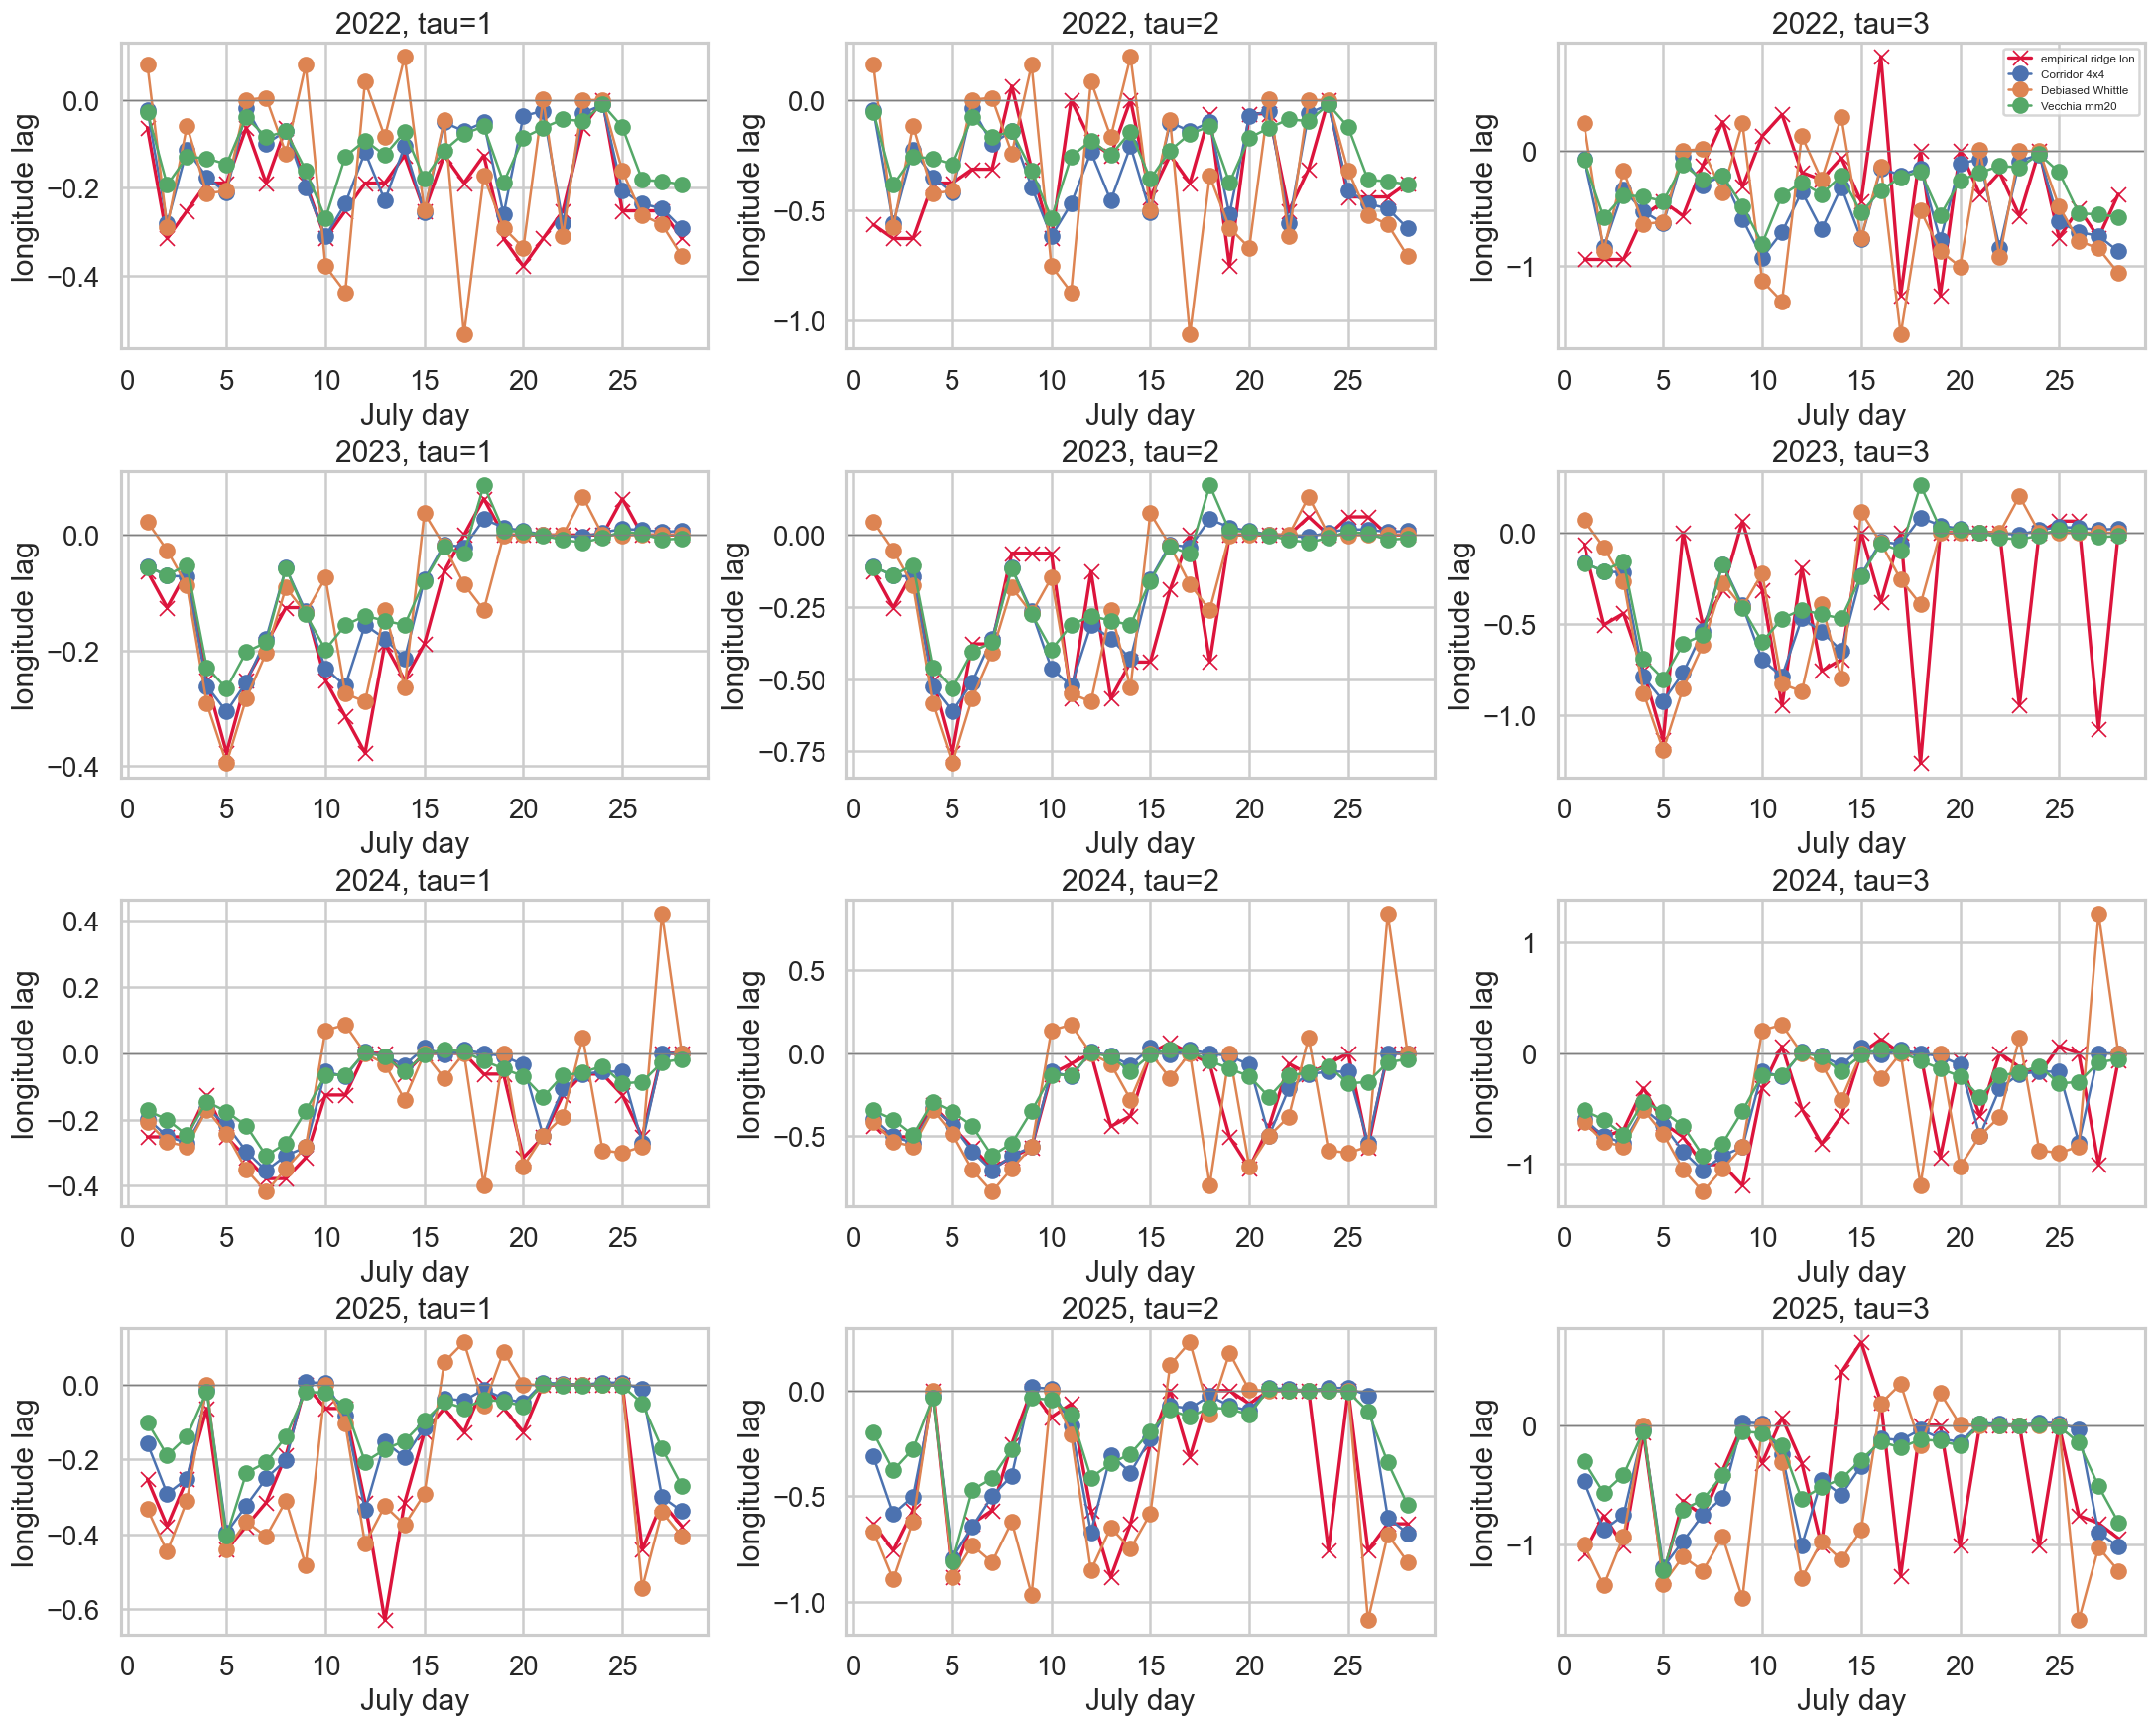

In [10]:
# Summary plot 1: empirical ridge longitude path and model advection longitude*tau, faceted by year.
summary = comparison_summary.copy()
fig, axes = plt.subplots(len(YEARS), len(TAUS), figsize=(6.0 * len(TAUS), 3.6 * len(YEARS)), constrained_layout=True, sharex=False)
for i, year in enumerate(YEARS):
    for j, tau in enumerate(TAUS):
        ax = axes[i, j]
        sub = summary.loc[summary['year'].eq(year) & summary['tau'].eq(tau)].copy()
        emp = sub.drop_duplicates(['year', 'day_num', 'tau']).sort_values('day_num')
        ax.plot(emp['day_num'], emp['ridge_lon_lag'], color='crimson', marker='x', lw=2.0, label='empirical ridge lon')
        for model, grp in sub.groupby('model'):
            grp = grp.sort_values('day_num')
            label = MODEL_STYLE.get(model, {}).get('label', model)
            ax.plot(grp['day_num'], grp['model_lon_lag'], marker='o', lw=1.5, label=label)
        ax.axhline(0, color='0.5', lw=0.8)
        ax.set_title(f'{year}, tau={tau}')
        ax.set_xlabel('July day')
        ax.set_ylabel('longitude lag')
        if i == 0 and j == len(TAUS) - 1:
            ax.legend(fontsize=7, loc='best')
summary_lon_path = OUTPUT_DIR / 'summary_lon_ridge_vs_models_by_year_tau.png'
fig.savefig(summary_lon_path, bbox_inches='tight')
print(f'Saved {summary_lon_path}')
plt.show()


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/summary_ridge_model_error_by_year_2022_2025_07.png


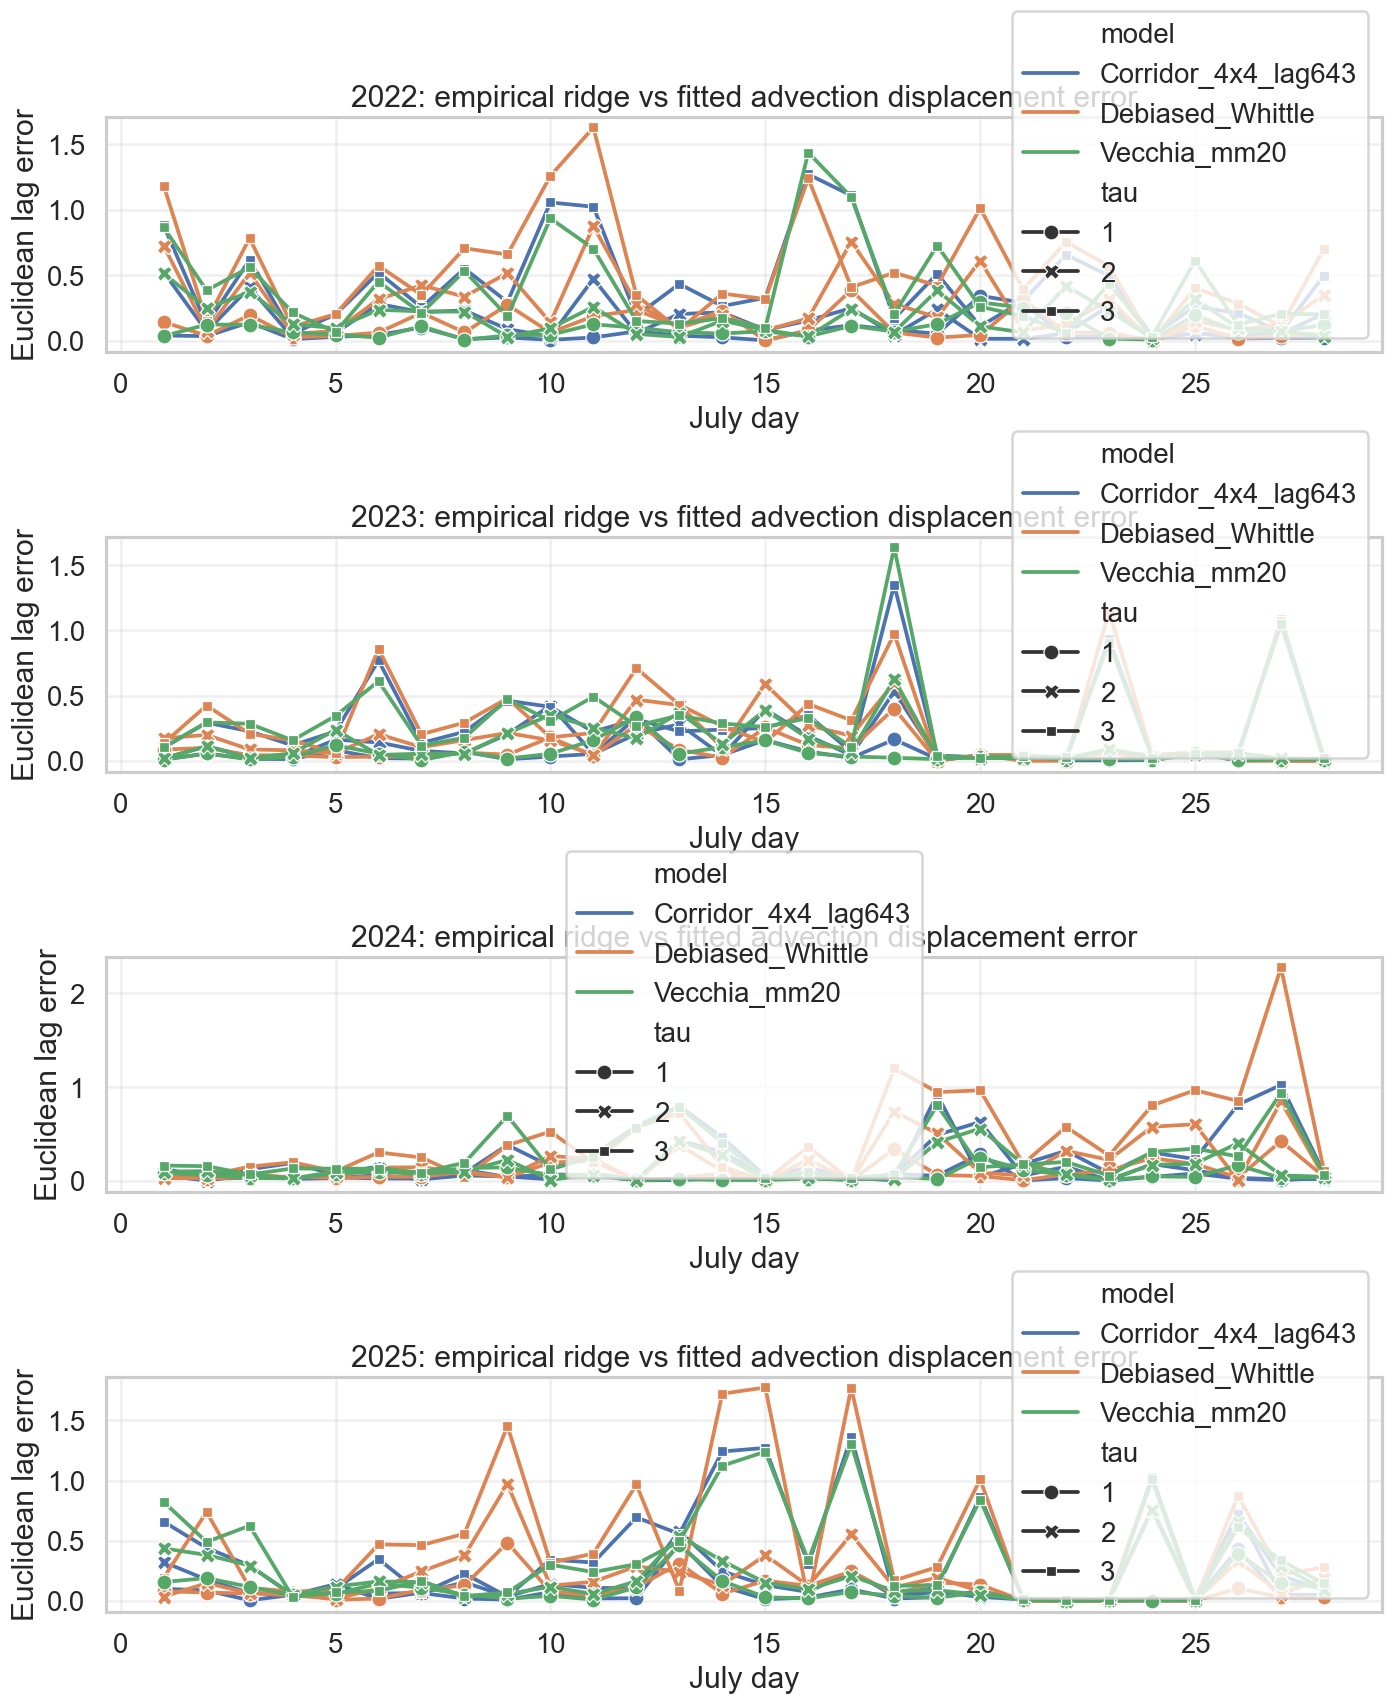

,count,mean,median,std,min,max
model,,,,,,
Corridor_4x4_lag643,336,0.1830,0.0670,0.2624,0.0006,1.3617
Vecchia_mm20,336,0.1930,0.1005,0.2519,0.0010,1.6369
Debiased_Whittle,336,0.2597,0.1251,0.3409,0.0000,2.2729


In [11]:
# Summary plot 2: Euclidean ridge-model error by year.
fig, axes = plt.subplots(len(YEARS), 1, figsize=(11.5, 3.5 * len(YEARS)), constrained_layout=True, sharex=False)
for ax, year in zip(np.atleast_1d(axes), YEARS):
    sub = comparison_summary.loc[comparison_summary['year'].eq(year)].copy()
    sns.lineplot(data=sub, x='day_num', y='err_euclid', hue='model', style='tau', markers=True, dashes=False, ax=ax)
    ax.set_title(f'{year}: empirical ridge vs fitted advection displacement error')
    ax.set_xlabel('July day')
    ax.set_ylabel('Euclidean lag error')
    ax.grid(True, alpha=0.3)
summary_error_path = OUTPUT_DIR / 'summary_ridge_model_error_by_year_2022_2025_07.png'
fig.savefig(summary_error_path, bbox_inches='tight')
print(f'Saved {summary_error_path}')
plt.show()

error_table = comparison_summary.groupby('model')['err_euclid'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(4).sort_values('mean')
error_by_year_tau = comparison_summary.groupby(['year', 'tau', 'model'])['err_euclid'].agg(['count', 'mean', 'median']).round(4).reset_index()
error_table.to_csv(OUTPUT_DIR / 'overall_model_error_summary_2022_2025_07.csv', float_format='%.4f')
error_by_year_tau.to_csv(OUTPUT_DIR / 'model_error_by_year_tau_2022_2025_07.csv', index=False, float_format='%.4f')
display(error_table)


In [12]:
# Summary plot 3: model parameter trajectories by year.
plot_params = ['sigma', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget']
for year in YEARS:
    year_dir = OUTPUT_DIR / f'year_{year}'
    fig, axes = plt.subplots(4, 2, figsize=(13, 12), constrained_layout=True)
    axes = axes.ravel()
    sub = estimates.loc[estimates['year'].eq(year)].copy()
    for ax, param in zip(axes, plot_params):
        sns.lineplot(data=sub, x='day_num', y=param, hue='model', marker='o', ax=ax)
        ax.set_title(f'{year} {param}')
        ax.set_xlabel('July day')
        ax.set_ylabel(param)
        ax.grid(True, alpha=0.3)
    axes[-1].axis('off')
    param_plot_path = year_dir / f'summary_three_model_parameters_{year}_07.png'
    fig.savefig(param_plot_path, bbox_inches='tight')
    print(f'Saved {param_plot_path}')
    plt.close(fig)


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/year_2022/summary_three_model_parameters_2022_07.png


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/year_2023/summary_three_model_parameters_2023_07.png


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/year_2024/summary_three_model_parameters_2024_07.png


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/year_2025/summary_three_model_parameters_2025_07.png


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/large_empirical_ridge_error_boxplot_norm_ge_1.0.png


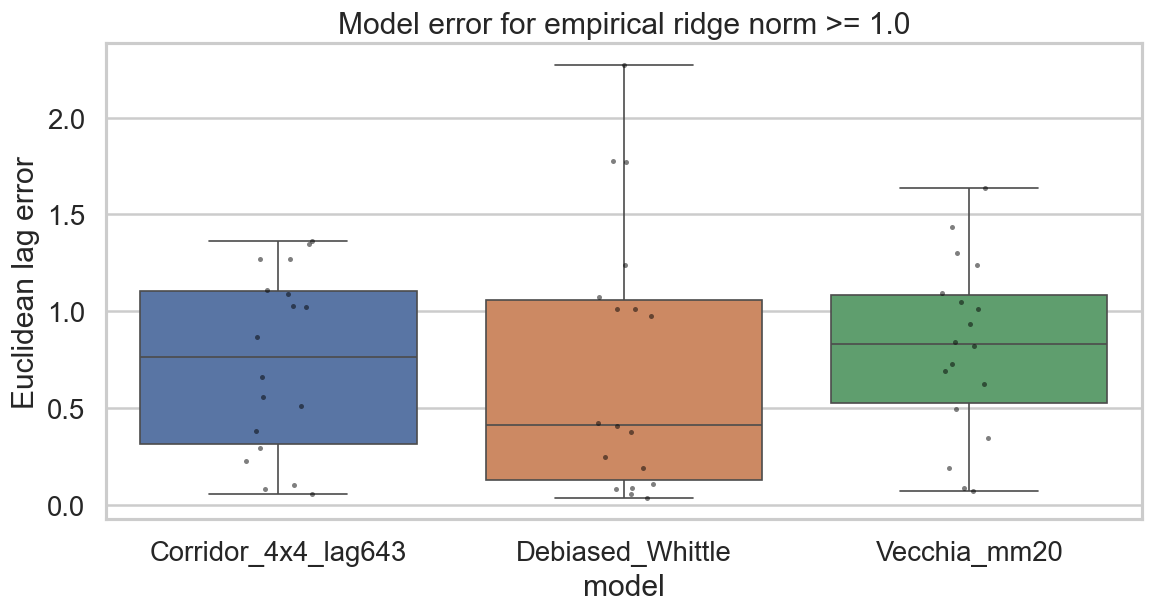

Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/large_empirical_ridge_cases_norm_ge_1.0.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/large_empirical_ridge_model_performance_norm_ge_1.0.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/large_empirical_ridge_model_performance_by_year_tau_norm_ge_1.0.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/ridge_ambiguity_summary_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_model_compare_2022_2025_052526/ridge_ambiguity_by_year_tau_2022_2025_07.csv
Large empirical ridge cases: 18


,count,mean,median,std,min,max
model,,,,,,
Debiased_Whittle,18,0.7308,0.4152,0.6919,0.0374,2.2729
Corridor_4x4_lag643,18,0.7351,0.7626,0.4698,0.0541,1.3617
Vecchia_mm20,18,0.8112,0.8316,0.4550,0.0705,1.6369


,year,tau,n,ambiguous_count,median_near_min_count,median_gamma_rel_gap,max_ridge_norm,ambiguous_rate
0,2022,1,28,20,6.0,0.0030,0.3806,0.7143
1,2022,2,28,27,16.5,0.0006,0.7573,0.9643
2,2022,3,28,28,25.5,0.0004,1.2971,1.0000
3,2023,1,28,9,4.0,0.0022,0.4374,0.3214
4,2023,2,28,21,11.5,0.0006,0.7611,0.7500
5,2023,3,28,27,26.0,0.0005,1.2722,0.9643
6,2024,1,28,13,4.0,0.0024,0.3881,0.4643
7,2024,2,28,26,11.5,0.0012,0.6986,0.9286
8,2024,3,28,27,19.5,0.0006,1.2002,0.9643
9,2025,1,28,12,4.0,0.0018,0.6361,0.4286


In [13]:
# Large-advection subset and ridge ambiguity diagnostics.
large = comparison_summary.loc[comparison_summary['large_empirical_ridge'].astype(bool)].copy()
large_cases = ridge_summary.loc[ridge_summary['ridge_norm'] >= LARGE_RIDGE_NORM_THRESHOLD].copy()

large_cases_path = OUTPUT_DIR / f'large_empirical_ridge_cases_norm_ge_{LARGE_RIDGE_NORM_THRESHOLD:.1f}.csv'
large_perf_path = OUTPUT_DIR / f'large_empirical_ridge_model_performance_norm_ge_{LARGE_RIDGE_NORM_THRESHOLD:.1f}.csv'
large_perf_by_year_tau_path = OUTPUT_DIR / f'large_empirical_ridge_model_performance_by_year_tau_norm_ge_{LARGE_RIDGE_NORM_THRESHOLD:.1f}.csv'
ambiguity_path = OUTPUT_DIR / 'ridge_ambiguity_summary_2022_2025_07.csv'
ambiguity_by_year_tau_path = OUTPUT_DIR / 'ridge_ambiguity_by_year_tau_2022_2025_07.csv'

large_cases.round(4).to_csv(large_cases_path, index=False, float_format='%.4f')
if len(large):
    large_perf = large.groupby('model')['err_euclid'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(4).sort_values('mean')
    large_perf_by_year_tau = large.groupby(['year', 'tau', 'model'])['err_euclid'].agg(['count', 'mean', 'median']).round(4).reset_index()
    large_perf.to_csv(large_perf_path, float_format='%.4f')
    large_perf_by_year_tau.to_csv(large_perf_by_year_tau_path, index=False, float_format='%.4f')

    fig, ax = plt.subplots(figsize=(9.5, 5.0), constrained_layout=True)
    sns.boxplot(data=large, x='model', y='err_euclid', hue='model', dodge=False, ax=ax)
    sns.stripplot(data=large, x='model', y='err_euclid', color='black', size=3, alpha=0.5, ax=ax)
    ax.legend_.remove() if ax.legend_ else None
    ax.set_title(f'Model error for empirical ridge norm >= {LARGE_RIDGE_NORM_THRESHOLD:.1f}')
    ax.set_xlabel('model')
    ax.set_ylabel('Euclidean lag error')
    large_plot_path = OUTPUT_DIR / f'large_empirical_ridge_error_boxplot_norm_ge_{LARGE_RIDGE_NORM_THRESHOLD:.1f}.png'
    fig.savefig(large_plot_path, bbox_inches='tight')
    print(f'Saved {large_plot_path}')
    plt.show()
else:
    large_perf = pd.DataFrame()
    large_perf_by_year_tau = pd.DataFrame()
    print(f'No empirical ridge cases with norm >= {LARGE_RIDGE_NORM_THRESHOLD:.1f}')

ambiguity_cols = ['year', 'month', 'day_num', 'tau', 'lat_lag', 'lon_lag', 'ridge_norm', 'gamma_min', 'gamma_second_min', 'gamma_gap', 'gamma_rel_gap', 'near_min_count', 'near_min_tol', 'is_ambiguous', 'n_pairs', 'lat_step', 'lon_step']
ridge_summary[ambiguity_cols].round(4).to_csv(ambiguity_path, index=False, float_format='%.4f')
ambiguity_by_year_tau = ridge_summary.groupby(['year', 'tau']).agg(
    n=('is_ambiguous', 'size'),
    ambiguous_count=('is_ambiguous', 'sum'),
    median_near_min_count=('near_min_count', 'median'),
    median_gamma_rel_gap=('gamma_rel_gap', 'median'),
    max_ridge_norm=('ridge_norm', 'max'),
).reset_index()
ambiguity_by_year_tau['ambiguous_rate'] = ambiguity_by_year_tau['ambiguous_count'] / ambiguity_by_year_tau['n']
ambiguity_by_year_tau.round(4).to_csv(ambiguity_by_year_tau_path, index=False, float_format='%.4f')

print(f'Saved {large_cases_path}')
print(f'Saved {large_perf_path}')
print(f'Saved {large_perf_by_year_tau_path}')
print(f'Saved {ambiguity_path}')
print(f'Saved {ambiguity_by_year_tau_path}')
print('Large empirical ridge cases:', len(large_cases))
if len(large_perf):
    display(large_perf)
display(ambiguity_by_year_tau.round(4).head(12))


In [ ]:
# Norm bias diagnostic: positive norm_bias means the model displacement magnitude exceeds the empirical ridge magnitude.
bias = comparison_summary.copy()
bias['norm_bias'] = bias['model_norm'] - bias['ridge_norm']
bias['abs_norm_bias'] = bias['norm_bias'].abs()
bias['overestimated_norm'] = bias['norm_bias'] > 0
large_bias = bias.loc[bias['large_empirical_ridge'].astype(bool)].copy()

def summarize_bias(df):
    if df.empty:
        return pd.DataFrame()
    out = df.groupby('model').agg(
        count=('norm_bias', 'size'),
        mean_norm_bias=('norm_bias', 'mean'),
        median_norm_bias=('norm_bias', 'median'),
        mean_abs_norm_bias=('abs_norm_bias', 'mean'),
        median_abs_norm_bias=('abs_norm_bias', 'median'),
        over_rate=('overestimated_norm', 'mean'),
        mean_err_euclid=('err_euclid', 'mean'),
        median_err_euclid=('err_euclid', 'median'),
    ).round(4).sort_values('mean_abs_norm_bias')
    return out

bias_summary = summarize_bias(bias)
large_bias_summary = summarize_bias(large_bias)
bias_by_year_tau = bias.groupby(['year', 'tau', 'model']).agg(
    count=('norm_bias', 'size'),
    mean_norm_bias=('norm_bias', 'mean'),
    median_norm_bias=('norm_bias', 'median'),
    over_rate=('overestimated_norm', 'mean'),
    mean_abs_norm_bias=('abs_norm_bias', 'mean'),
).round(4).reset_index()
large_bias_by_year_tau = large_bias.groupby(['year', 'tau', 'model']).agg(
    count=('norm_bias', 'size'),
    mean_norm_bias=('norm_bias', 'mean'),
    median_norm_bias=('norm_bias', 'median'),
    over_rate=('overestimated_norm', 'mean'),
    mean_abs_norm_bias=('abs_norm_bias', 'mean'),
).round(4).reset_index() if len(large_bias) else pd.DataFrame()

bias_summary.to_csv(OUTPUT_DIR / 'model_norm_bias_summary_2022_2025_07.csv', float_format='%.4f')
large_bias_summary.to_csv(OUTPUT_DIR / f'large_empirical_ridge_model_norm_bias_norm_ge_{LARGE_RIDGE_NORM_THRESHOLD:.1f}.csv', float_format='%.4f')
bias_by_year_tau.to_csv(OUTPUT_DIR / 'model_norm_bias_by_year_tau_2022_2025_07.csv', index=False, float_format='%.4f')
if len(large_bias_by_year_tau):
    large_bias_by_year_tau.to_csv(OUTPUT_DIR / f'large_empirical_ridge_model_norm_bias_by_year_tau_norm_ge_{LARGE_RIDGE_NORM_THRESHOLD:.1f}.csv', index=False, float_format='%.4f')

print('Overall norm-bias summary')
display(bias_summary)
print('Large empirical ridge norm-bias summary')
display(large_bias_summary)


## Interpretation notes

- Heatmaps and red X markers are empirical. The fitted models are only overlaid through `advec_lat*tau` and `advec_lon*tau`.
- The red X is rigorous in the operational sense: it is the global minimum of the pair-count-filtered, smoothed empirical semivariogram surface. It is not automatically a precise physical point when the surface is flat or has several nearly equal minima.
- `near_min_count`, `gamma_gap`, and `gamma_rel_gap` quantify that ambiguity. Large `near_min_count` or tiny `gamma_rel_gap` means the X should be read as a ridge region, not a single sharply identified point.
- The large-advection subset is based on empirical ridge norm, not a model estimate, so it can compare the three models without letting one model define the event.
- Numeric saved tables use 4 decimal places.
